In [10]:
# ПРАКТИЧЕСКАЯ РАБОТА 2 - ВАРИАНТ 30
# ЗАГРУЗКА ДАННЫХ: MongoDB, Cassandra, RDF
# ============================================

# Установка библиотек (если ещё не установлены)
!pip install Faker pymongo cassandra-driver

from faker import Faker
from pymongo import MongoClient
from cassandra.cluster import Cluster
import random
import uuid
from datetime import datetime

fake = Faker()

# ============================================
# 1. ИНИЦИАЛИЗАЦИЯ ПОДКЛЮЧЕНИЙ
# ============================================
# MongoDB
mongo_client = MongoClient(
    host='localhost',
    port=27017,
    username='root',
    password='abc123!',
    authSource='admin'  # обычно пользователь root создаётся в базе admin
)
mongo_db = mongo_client["streaming_db"]
movies_col = mongo_db["movies"]
movies_col.drop()  # очистим коллекцию перед заполнением

# Cassandra
cass_cluster = Cluster(['localhost'], port=29042)
cass_session = cass_cluster.connect()

# Создаём keyspace (если нет) с фактором репликации 1 для учебных целей
cass_session.execute("""
    CREATE KEYSPACE IF NOT EXISTS streaming_logs
    WITH replication = {'class': 'SimpleStrategy', 'replication_factor': 1}
""")
cass_session.set_keyspace('streaming_logs')

# Создаём таблицу для логов с настроенной стратегией сжатия (LZ4)
cass_session.execute("""
    CREATE TABLE IF NOT EXISTS watch_logs (
        movie_id TEXT,
        user_id UUID,
        timestamp TIMESTAMP,
        watch_duration_min INT,
        PRIMARY KEY (user_id, timestamp)
    ) WITH CLUSTERING ORDER BY (timestamp DESC)
      AND compression = {'sstable_compression': 'LZ4Compressor', 'chunk_length_kb': 64}
""")

# Очистим таблицу от старых данных (если нужно)
cass_session.execute("TRUNCATE watch_logs")

print("Инфраструктура подготовлена: MongoDB и Cassandra готовы к работе.")

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Инфраструктура подготовлена: MongoDB и Cassandra готовы к работе.


In [11]:
# ============================================
# 2. ГЕНЕРАЦИЯ ДАННЫХ
# ============================================
genres = ["Action", "Comedy", "Drama", "Sci-Fi", "Thriller", "Horror", "Romance"]
actors_pool = [
    "Keanu Reeves", "Leonardo DiCaprio", "Scarlett Johansson", "Robert Downey Jr.",
    "Tom Hanks", "Natalie Portman", "Brad Pitt", "Angelina Jolie", "Johnny Depp",
    "Meryl Streep", "Denzel Washington", "Jennifer Lawrence", "Christian Bale"
]
directors_pool = [
    "Christopher Nolan", "Quentin Tarantino", "Steven Spielberg", "Martin Scorsese",
    "James Cameron", "Ridley Scott", "Peter Jackson", "Lana Wachowski", "David Fincher",
    "Keanu Reeves", "Clint Eastwood", "Ron Howard", "Greta Gerwig"
]

# Список для хранения данных фильмов (для RDF)
movies_data = []
movie_ids = []

# Генерация 50 фильмов
for i in range(1, 51):
    movie_id = f"Movie_{i:03d}"
    movie_ids.append(movie_id)
    
    title = fake.catch_phrase().replace(" ", "_")
    genre = random.choice(genres)
    rating = round(random.uniform(3.0, 9.8), 1)
    
    # Определяем, есть ли Киану Ривз в актёрском составе (примерно 30% фильмов)
    has_keanu = random.random() < 0.3
    num_actors = random.randint(2, 4)
    if has_keanu:
        actors = ["Keanu Reeves"] + random.sample([a for a in actors_pool if a != "Keanu Reeves"], num_actors - 1)
    else:
        actors = random.sample(actors_pool, num_actors)
    
    # Выбираем режиссёра (может совпасть с актёром)
    director = random.choice(directors_pool)
    
    # Создаём документ для MongoDB
    movie_doc = {
        "_id": movie_id,
        "title": title,
        "genre": genre,
        "rating": rating,
        "actors": actors,
        "director": director
    }
    movies_col.insert_one(movie_doc)
    
    # Сохраняем для RDF
    movies_data.append({
        "id": movie_id,
        "title": title,
        "genre": genre,
        "rating": rating,
        "actors": actors,
        "director": director
    })

print(f"[MongoDB] Сгенерировано {len(movies_data)} фильмов.")

# Генерация логов просмотров (1000 записей)
for _ in range(1000):
    movie_id = random.choice(movie_ids)
    user_id = uuid.uuid4()
    # случайное время за последний год
    ts = fake.date_time_between(start_date='-1y', end_date='now')
    watch_duration = random.randint(5, 240)
    cass_session.execute(
        "INSERT INTO watch_logs (movie_id, user_id, timestamp, watch_duration_min) VALUES (%s, %s, %s, %s)",
        (movie_id, user_id, ts, watch_duration)
    )

print(f"[Cassandra] Сгенерировано 1000 записей логов просмотров.")

# Генерация RDF-файла для GraphDB (Turtle)
rdf_lines = [
    "@prefix ex: <http://example.org/streaming#> .",
    "@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .",
    ""
]

for m in movies_data:
    rdf_lines.append(f"ex:{m['id']} a ex:Movie ;")
    rdf_lines.append(f'    ex:title "{m["title"]}" ;')
    rdf_lines.append(f'    ex:genre "{m["genre"]}" ;')
    rdf_lines.append(f'    ex:rating "{m["rating"]}"^^xsd:decimal ;')
    for actor in m['actors']:
        rdf_lines.append(f'    ex:hasActor "{actor}" ;')
    rdf_lines.append(f'    ex:hasDirector "{m["director"]}" .')
    rdf_lines.append("")

# Сохраняем файл
with open("movies_graph.ttl", "w", encoding="utf-8") as f:
    f.write("\n".join(rdf_lines))

print("[RDF] Файл 'movies_graph.ttl' создан.")

[MongoDB] Сгенерировано 50 фильмов.
[Cassandra] Сгенерировано 1000 записей логов просмотров.
[RDF] Файл 'movies_graph.ttl' создан.


In [18]:
# ============================================
# 3. ПРОВЕРКА ДАННЫХ И ПОЯСНЕНИЯ
# ============================================
print("\n===========================================")
print("ПРОВЕРКА СОЗДАННЫХ БАЗ ДАННЫХ")
print("===========================================\n")

# Проверка MongoDB
mongo_count = movies_col.count_documents({})
sample_movie = movies_col.find_one()
print("--- 1. Проверка MongoDB (Document Store) ---")
print(f"[ДАННЫЕ]: Всего документов: {mongo_count}")
print(f"[ДАННЫЕ]: Пример документа: {sample_movie}")
print("[ПОЯСНЕНИЕ]: MongoDB успешно сохранила JSON-документы с информацией о фильмах. "
      "Гибкая схема позволяет хранить разнородные данные (актёры, режиссёр, рейтинг) "
      "в одном документе, что удобно для каталога стримингового сервиса.\n")

# Проверка Cassandra
cass_count = cass_session.execute("SELECT COUNT(*) FROM watch_logs").one()[0]
sample_log = cass_session.execute("SELECT * FROM watch_logs LIMIT 1").one()
print("--- 2. Проверка Cassandra (Wide-Column Store) ---")
print(f"[ДАННЫЕ]: Всего записано логов просмотров: {cass_count}")
print(f"[ДАННЫЕ]: Пример записи (строка): {sample_log}")
print("[ПОЯСНЕНИЕ]: Cassandra отлично подходит для записи потоковых данных (логов). "
      "Мы использовали партиционирование по user_id и кластеризацию по timestamp DESC, "
      "что позволяет быстро получать последние действия конкретного пользователя. "
      "Дополнительно настроена стратегия сжатия LZ4 для экономии места на диске.\n")


ПРОВЕРКА СОЗДАННЫХ БАЗ ДАННЫХ

--- 1. Проверка MongoDB (Document Store) ---
[ДАННЫЕ]: Всего документов: 50
[ДАННЫЕ]: Пример документа: {'_id': 'Movie_001', 'title': 'Cross-group_systemic_software', 'genre': 'Romance', 'rating': 7.2, 'actors': ['Natalie Portman', 'Meryl Streep'], 'director': 'Keanu Reeves'}
[ПОЯСНЕНИЕ]: MongoDB успешно сохранила JSON-документы с информацией о фильмах. Гибкая схема позволяет хранить разнородные данные (актёры, режиссёр, рейтинг) в одном документе, что удобно для каталога стримингового сервиса.

--- 2. Проверка Cassandra (Wide-Column Store) ---
[ДАННЫЕ]: Всего записано логов просмотров: 1000
[ДАННЫЕ]: Пример записи (строка): Row(user_id=UUID('187625f0-e5c0-4f22-9cc0-a013d48f0115'), timestamp=datetime.datetime(2025, 8, 8, 7, 12, 25, 864000), movie_id='Movie_014', watch_duration_min=35)
[ПОЯСНЕНИЕ]: Cassandra отлично подходит для записи потоковых данных (логов). Мы использовали партиционирование по user_id и кластеризацию по timestamp DESC, что позволяет б

In [20]:
# Задание 1. Cassandra. Сжатие таблиц. Настройка стратегии компрессии. 
compression_info = cass_session.execute("""
    SELECT compression FROM system_schema.tables 
    WHERE keyspace_name='streaming_logs' AND table_name='watch_logs'
""").one()
print("--- 3. Проверка стратегии сжатия в Cassandra ---")
print(f"[ДАННЫЕ]: Текущие параметры сжатия: {compression_info.compression}")
print("[ПОЯСНЕНИЕ]: Параметры сжатия заданы при создании таблицы. "
      "При необходимости их можно изменить командой ALTER TABLE.\n")

print("Все данные успешно загружены.")

--- 3. Проверка стратегии сжатия в Cassandra ---
[ДАННЫЕ]: Текущие параметры сжатия: {'chunk_length_in_kb': '64', 'class': 'org.apache.cassandra.io.compress.LZ4Compressor'}
[ПОЯСНЕНИЕ]: Параметры сжатия заданы при создании таблицы. При необходимости их можно изменить командой ALTER TABLE.

Все данные успешно загружены.


In [14]:
!pip install SPARQLWrapper pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 8.1 MB/s  0:00:00
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [rdflib]  WARNING: The scripts csv2rdf, rdf2dot, rdfgraphisomorphism, rdfpipe, rdfs2dot and sparqlquery are installed in '/home/dev/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [SPARQLWrapper]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [15]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

# Укажите URL вашего репозитория 
sparql = SPARQLWrapper("http://localhost:17200/repositories/movies_repo")

# ============================================
# Запрос 1. Фильмы с Киану Ривзом
# ============================================
query1 = """
PREFIX ex: <http://example.org/streaming#>
SELECT ?movie ?title ?rating WHERE {
    ?movie a ex:Movie ;
           ex:title ?title ;
           ex:rating ?rating ;
           ex:hasActor "Keanu Reeves" .
}
ORDER BY DESC(?rating)
"""
sparql.setQuery(query1)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data1 = []
for res in results["results"]["bindings"]:
    data1.append({
        "movie": res["movie"]["value"].split('#')[-1],
        "title": res["title"]["value"],
        "rating": float(res["rating"]["value"])
    })
df_keanu = pd.DataFrame(data1)
print("--- Фильмы с Киану Ривзом ---")
print(df_keanu)
print(f"Всего фильмов с Киану: {len(df_keanu)}\n")

--- Фильмы с Киану Ривзом ---
        movie                                        title  rating
0   Movie_003            Upgradable_scalable_collaboration     9.3
1   Movie_014         Persevering_upward-trending_hardware     9.2
2   Movie_032             Ameliorated_responsive_moderator     9.2
3   Movie_026  Cross-platform_content-based_infrastructure     8.9
4   Movie_050              Progressive_motivating_extranet     8.7
5   Movie_018             Switchable_didactic_productivity     8.5
6   Movie_039            Optional_system-worthy_monitoring     8.4
7   Movie_034             Networked_multimedia_focus_group     8.2
8   Movie_046       Proactive_intermediate_instruction_set     7.9
9   Movie_004         Quality-focused_motivating_structure     7.7
10  Movie_043          Devolved_directional_infrastructure     7.3
11  Movie_033  Cloned_encompassing_artificial_intelligence     6.9
12  Movie_035             Horizontal_background_time-frame     6.7
13  Movie_036         Multi-chan

In [16]:
# ============================================
# Запрос 2. Фильмы с рейтингом > 8.0
# ============================================
query2 = """
PREFIX ex: <http://example.org/streaming#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
SELECT ?movie ?title ?rating WHERE {
    ?movie a ex:Movie ;
           ex:title ?title ;
           ex:rating ?rating .
    FILTER (xsd:decimal(?rating) > 8.0)
}
ORDER BY DESC(?rating)
"""
sparql.setQuery(query2)
results = sparql.query().convert()

data2 = []
for res in results["results"]["bindings"]:
    data2.append({
        "movie": res["movie"]["value"].split('#')[-1],
        "title": res["title"]["value"],
        "rating": float(res["rating"]["value"])
    })
df_high_rating = pd.DataFrame(data2)
print("--- Фильмы с рейтингом > 8.0 ---")
print(df_high_rating)
print(f"Всего фильмов с рейтингом > 8.0: {len(df_high_rating)}\n")

--- Фильмы с рейтингом > 8.0 ---
        movie                                        title  rating
0   Movie_006            Visionary_web-enabled_open_system     9.8
1   Movie_041            Persistent_fault-tolerant_concept     9.6
2   Movie_003            Upgradable_scalable_collaboration     9.3
3   Movie_014         Persevering_upward-trending_hardware     9.2
4   Movie_032             Ameliorated_responsive_moderator     9.2
5   Movie_013       Multi-lateral_object-oriented_strategy     9.1
6   Movie_026  Cross-platform_content-based_infrastructure     8.9
7   Movie_050              Progressive_motivating_extranet     8.7
8   Movie_018             Switchable_didactic_productivity     8.5
9   Movie_007      Cross-platform_next_generation_leverage     8.4
10  Movie_039            Optional_system-worthy_monitoring     8.4
11  Movie_012           Compatible_client-driven_emulation     8.2
12  Movie_029      De-engineered_full-range_knowledge_user     8.2
13  Movie_034             Net

In [21]:
# ============================================
# Запрос 3. Актеры, которые также являются режиссерами
# ============================================
query3 = """
PREFIX ex: <http://example.org/streaming#>
SELECT DISTINCT ?person WHERE {
    ?movie a ex:Movie ;
           ex:hasActor ?person ;
           ex:hasDirector ?person .
}
"""
sparql.setQuery(query3)
results = sparql.query().convert()

data3 = []
for res in results["results"]["bindings"]:
    data3.append({"actor_director": res["person"]["value"]})
df_actors_directors = pd.DataFrame(data3)
print("--- Люди, которые в одном фильме являются и актёром, и режиссёром ---")
print(df_actors_directors)

--- Люди, которые в одном фильме являются и актёром, и режиссёром ---
  actor_director
0   Keanu Reeves


========== СТАТИСТИЧЕСКИЙ ОБЗОР ==========
Фильмов с Киану Ривзом: 26
Средний рейтинг фильмов с Киану: 6.77
Фильмов без Киану: 24
Средний рейтинг фильмов без Киану: 6.66
Разница: +0.11


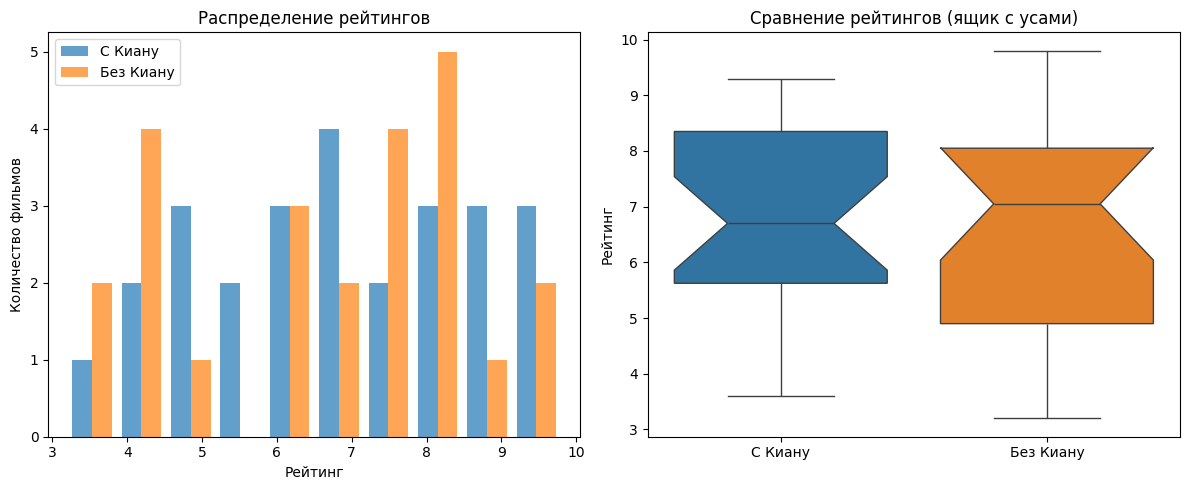

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pymongo import MongoClient

# Получаем все фильмы
all_movies = list(movies_col.find({}, {"_id": 0, "title": 1, "rating": 1, "actors": 1}))

# Разделяем на группы
keanu_movies = [m for m in all_movies if "Keanu Reeves" in m["actors"]]
other_movies = [m for m in all_movies if "Keanu Reeves" not in m["actors"]]

# Средние рейтинги
def avg_rating(movies):
    if not movies:
        return 0
    return sum(m["rating"] for m in movies) / len(movies)

avg_keanu = avg_rating(keanu_movies)
avg_other = avg_rating(other_movies)

print("========== СТАТИСТИЧЕСКИЙ ОБЗОР ==========")
print(f"Фильмов с Киану Ривзом: {len(keanu_movies)}")
print(f"Средний рейтинг фильмов с Киану: {avg_keanu:.2f}")
print(f"Фильмов без Киану: {len(other_movies)}")
print(f"Средний рейтинг фильмов без Киану: {avg_other:.2f}")
print(f"Разница: {avg_keanu - avg_other:+.2f}")

# Визуализация распределения
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ratings_keanu = [m["rating"] for m in keanu_movies]
ratings_other = [m["rating"] for m in other_movies]
plt.hist([ratings_keanu, ratings_other], bins=10, alpha=0.7, label=['С Киану', 'Без Киану'], color=['#1f77b4', '#ff7f0e'])
plt.xlabel('Рейтинг')
plt.ylabel('Количество фильмов')
plt.title('Распределение рейтингов')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=[ratings_keanu, ratings_other], notch=True)
plt.xticks([0, 1], ['С Киану', 'Без Киану'])
plt.ylabel('Рейтинг')
plt.title('Сравнение рейтингов (ящик с усами)')

plt.tight_layout()
plt.show()